# Neural Network
### UAE Used Car Price Prediction | CSCI323 | UOWD Spring 2026

## 1. Setup

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time, copy, joblib

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from torch.cuda.amp import GradScaler, autocast
from torch.optim.swa_utils import AveragedModel, SWALR, update_bn

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device} — {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"}')

Device: cpu — CPU


## 2. Load Data

In [19]:
df = pd.read_csv('../data/dubizzle_cleaned.csv')
print(f'Shape: {df.shape}')
df[['price_in_aed', 'kilometers', 'horsepower', 'age']].describe().round(0)

Shape: (8316, 1427)


,price_in_aed,kilometers,horsepower,age
count,8316.0,8316.0,8316.0,8316.0
mean,116410.0,101022.0,312.0,11.0
std,98340.0,69348.0,122.0,5.0
min,8900.0,0.0,125.0,5.0
25%,45000.0,47172.0,250.0,8.0
50%,82000.0,93000.0,250.0,10.0
75%,155000.0,145000.0,350.0,13.0
max,500000.0,500000.0,950.0,73.0


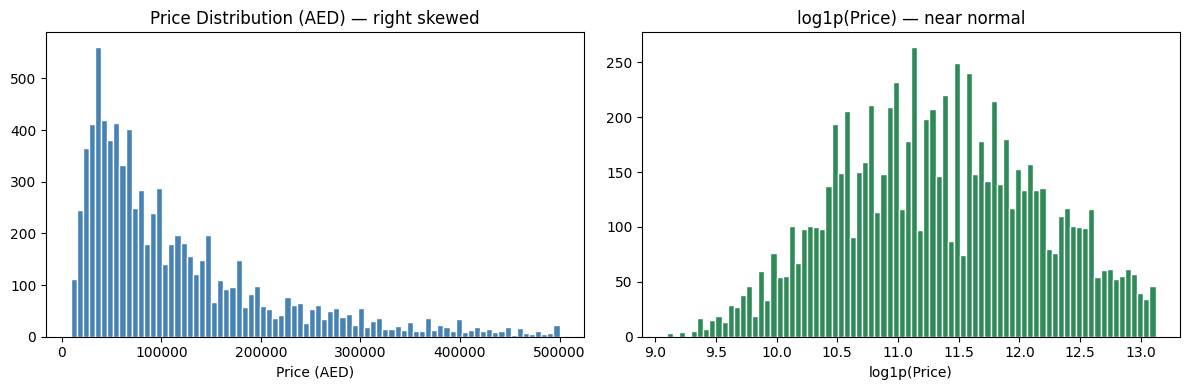

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['price_in_aed'], bins=80, color='steelblue', edgecolor='white')
axes[0].set_title('Price Distribution (AED) — right skewed')
axes[0].set_xlabel('Price (AED)')
axes[1].hist(np.log1p(df['price_in_aed']), bins=80, color='seagreen', edgecolor='white')
axes[1].set_title('log1p(Price) — near normal')
axes[1].set_xlabel('log1p(Price)')
plt.tight_layout()
plt.savefig('price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Feature Engineering

Several continuous columns are right-skewed — applying log1p and adding interaction terms gives the model useful pre-computed signals.

In [21]:
for col in ['kilometers', 'horsepower', 'km_per_year', 'age']:
    df['log_' + col] = np.log1p(df[col])

df['hp_per_cyl']    = df['horsepower'] / df['no_of_cylinders'].clip(lower=1)
df['km_per_hp']     = df['kilometers'] / df['horsepower'].clip(lower=1)
df['age_squared']   = df['age'] ** 2
df['hp_age']        = df['horsepower'] / (df['age'] + 1)
df['log_km_per_hp'] = np.log1p(df['km_per_hp'])

print(f'Total features: {df.shape[1] - 1}')

Total features: 1435


## 4. Train / Validation / Test Split

Same 70 / 15 / 15 split and random_state=42 as all other members so test results are directly comparable.

In [22]:
TARGET = 'price_in_aed'

X     = df.drop(columns=[TARGET]).values.astype(np.float32)
y_aed = df[TARGET].values.astype(np.float32)
y_log = np.log1p(y_aed)

idx = np.arange(len(X))
idx_train, idx_temp = train_test_split(idx, test_size=0.30, random_state=42)
idx_val,   idx_test = train_test_split(idx_temp, test_size=0.50, random_state=42)

X_train, X_val, X_test = X[idx_train], X[idx_val], X[idx_test]
y_train = y_log[idx_train]
y_val   = y_log[idx_val]
y_test  = y_aed[idx_test]

print(f'Train: {len(X_train)}  Val: {len(X_val)}  Test: {len(X_test)}')

Train: 5821  Val: 1247  Test: 1248


## 5. Scaling & Data Loaders

In [23]:
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_val   = scaler.transform(X_val).astype(np.float32)
X_test  = scaler.transform(X_test).astype(np.float32)

def make_loader(X, y, shuffle=True):
    ds = TensorDataset(torch.from_numpy(X), torch.from_numpy(y.astype(np.float32)).unsqueeze(1))
    return DataLoader(ds, batch_size=256, shuffle=shuffle, pin_memory=True, num_workers=0)

train_loader = make_loader(X_train, y_train)
val_loader   = make_loader(X_val,   y_val,   shuffle=False)

## 6. Model Architecture

Five dense blocks with BatchNorm, GELU activation and progressive dropout. GELU consistently outperforms ReLU on tabular benchmarks. The output layer is linear since we are predicting a continuous value (log-price).

In [24]:
class MLP(nn.Module):
    def __init__(self, n_features):
        super().__init__()

        def block(in_dim, out_dim, dropout):
            return nn.Sequential(
                nn.Linear(in_dim, out_dim),
                nn.BatchNorm1d(out_dim),
                nn.GELU(),
                nn.Dropout(dropout)
            )

        self.network = nn.Sequential(
            block(n_features, 1024, 0.40),
            block(1024,        512, 0.35),
            block( 512,        256, 0.25),
            block( 256,        128, 0.20),
            block( 128,         64, 0.15),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.GELU(),
            nn.Linear(32, 1)
        )

        for layer in self.modules():
            if isinstance(layer, nn.Linear):
                nn.init.kaiming_normal_(layer.weight)
                nn.init.zeros_(layer.bias)

    def forward(self, x):
        return self.network(x)


model = MLP(X_train.shape[1]).to(device)
print(f'Trainable parameters: {sum(p.numel() for p in model.parameters()):,}')

Trainable parameters: 2,173,889


## 7. Training — Phase 1

Two regularisation techniques from *Simple Modifications to Improve Tabular Neural Networks* (Gorishniy et al., 2021) are applied each batch:

- **MixUp**: linearly blends pairs of training samples, preventing the model from memorising individual points and improving generalisation
- **Input noise**: small Gaussian noise added to each batch stops the model from overfitting to exact feature values

SWA runs afterwards in Phase 2.

In [25]:
def mixup(x, y, alpha=0.3):
    lam = float(np.random.beta(alpha, alpha))
    shuffled = torch.randperm(x.size(0), device=x.device)
    return lam * x + (1 - lam) * x[shuffled], lam * y + (1 - lam) * y[shuffled]


criterion   = nn.MSELoss()
optimizer   = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=5e-5)
scheduler   = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=8, min_lr=1e-6)
grad_scaler = GradScaler()

PATIENCE = 25
best_loss, best_weights, best_epoch, no_improve = float('inf'), None, 0, 0
train_history, val_history = [], []
t0 = time.time()

for epoch in range(1, 201):
    model.train()
    train_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        xb = xb + torch.randn_like(xb) * 0.02
        xb, yb = mixup(xb, yb)
        optimizer.zero_grad()
        with autocast():
            loss = criterion(model(xb), yb)
        grad_scaler.scale(loss).backward()
        grad_scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        grad_scaler.step(optimizer)
        grad_scaler.update()
        train_loss += loss.item() * len(xb)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            with autocast():
                val_loss += criterion(model(xb), yb).item() * len(xb)

    train_loss /= len(X_train)
    val_loss   /= len(X_val)
    train_history.append(train_loss)
    val_history.append(val_loss)
    scheduler.step(val_loss)

    if val_loss < best_loss:
        best_loss, best_weights, best_epoch, no_improve = val_loss, copy.deepcopy(model.state_dict()), epoch, 0
    else:
        no_improve += 1

    if epoch % 10 == 0:
        lr = optimizer.param_groups[0]['lr']
        print(f'Epoch {epoch:>3}  train {train_loss:.5f}  val {val_loss:.5f}  lr {lr:.0e}  patience {no_improve}/{PATIENCE}')

    if no_improve >= PATIENCE:
        print(f'Early stopping at epoch {epoch}  |  best epoch: {best_epoch}')
        break

model.load_state_dict(best_weights)
print(f'Phase 1 complete — {time.time()-t0:.0f}s')

Epoch  10  train 52.67311  val 45.61570  lr 1e-03  patience 0/25
Epoch  20  train 2.09277  val 1.10506  lr 1e-03  patience 0/25
Epoch  30  train 0.26736  val 0.11846  lr 1e-03  patience 0/25
Epoch  40  train 0.18087  val 0.10416  lr 1e-03  patience 1/25
Epoch  50  train 0.14239  val 0.07910  lr 1e-03  patience 0/25
Epoch  60  train 0.11492  val 0.07909  lr 1e-03  patience 7/25
Epoch  70  train 0.09807  val 0.06835  lr 5e-04  patience 0/25
Epoch  80  train 0.08517  val 0.06837  lr 5e-04  patience 1/25
Epoch  90  train 0.07075  val 0.06816  lr 5e-04  patience 2/25
Epoch 100  train 0.07401  val 0.06628  lr 5e-04  patience 3/25
Epoch 110  train 0.06680  val 0.06771  lr 3e-04  patience 3/25
Epoch 120  train 0.05740  val 0.06500  lr 3e-04  patience 3/25
Epoch 130  train 0.06199  val 0.06318  lr 1e-04  patience 13/25
Epoch 140  train 0.05950  val 0.06531  lr 6e-05  patience 23/25
Early stopping at epoch 142  |  best epoch: 117
Phase 1 complete — 143s


## 8. Training — Phase 2 (Stochastic Weight Averaging)

SWA runs the optimiser for a further 60 epochs at a low fixed learning rate and averages the model weights across those epochs. This produces a flatter loss minimum that generalises better than any single checkpoint.

In [26]:
swa_model     = AveragedModel(model)
swa_scheduler = SWALR(optimizer, swa_lr=5e-5, anneal_epochs=15)

for epoch in range(60):
    model.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        xb = xb + torch.randn_like(xb) * 0.02
        xb, yb = mixup(xb, yb)
        optimizer.zero_grad()
        with autocast():
            loss = criterion(model(xb), yb)
        grad_scaler.scale(loss).backward()
        grad_scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        grad_scaler.step(optimizer)
        grad_scaler.update()
    swa_model.update_parameters(model)
    swa_scheduler.step()
    if (epoch + 1) % 20 == 0:
        print(f'SWA epoch {epoch + 1}/60')

update_bn(train_loader, swa_model, device=device)
print('SWA complete')

SWA epoch 20/60
SWA epoch 40/60
SWA epoch 60/60
SWA complete


## 9. Evaluation on Test Set

In [27]:
swa_model.eval()
with torch.no_grad():
    log_predictions = swa_model(torch.from_numpy(X_test).to(device)).cpu().numpy().flatten()

predictions = np.clip(np.expm1(log_predictions), 0, None)

rmse = np.sqrt(mean_squared_error(y_test, predictions))
mae  = mean_absolute_error(y_test, predictions)
r2   = r2_score(y_test, predictions)

print(f'R\u00b2   : {r2:.4f}')
print(f'RMSE : AED {rmse:,.0f}')
print(f'MAE  : AED {mae:,.0f}')

R²   : 0.8981
RMSE : AED 31,524
MAE  : AED 18,423


## 10. Training Loss Curve

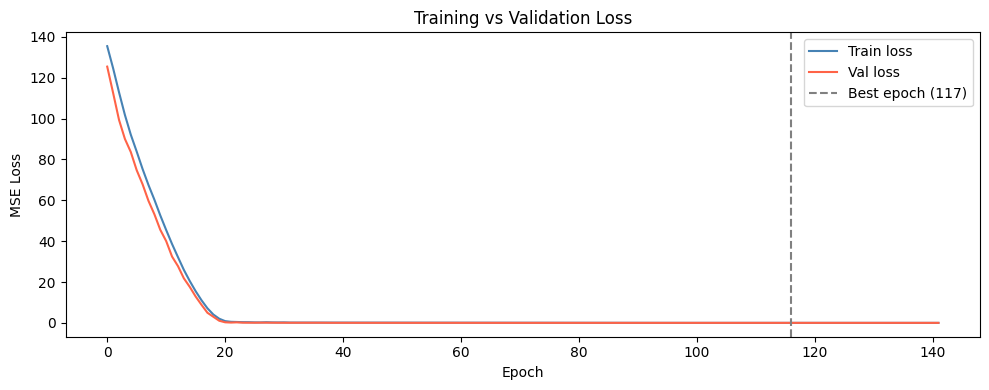

In [28]:
plt.figure(figsize=(10, 4))
plt.plot(train_history, label='Train loss', color='steelblue')
plt.plot(val_history,   label='Val loss',   color='tomato')
plt.axvline(best_epoch - 1, color='grey', linestyle='--', label=f'Best epoch ({best_epoch})')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.tight_layout()
plt.savefig('../plots/Neural Network/loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Actual vs Predicted

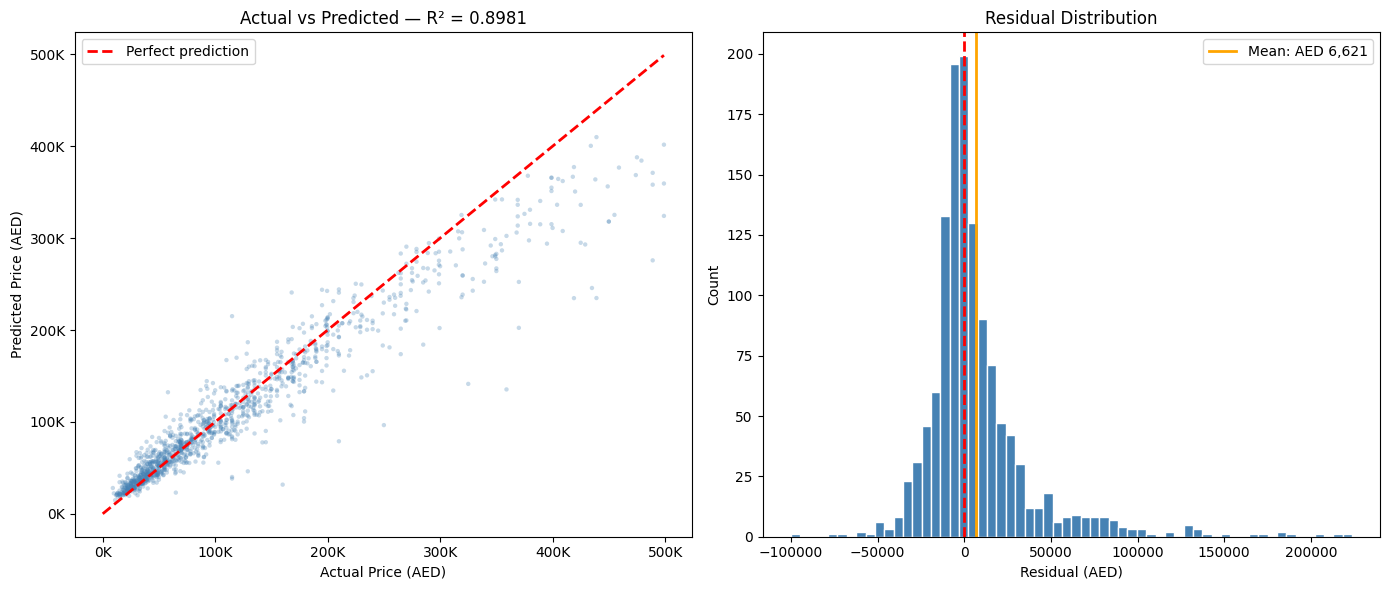

In [29]:
residuals = y_test - predictions

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

m = max(y_test.max(), predictions.max())
axes[0].scatter(y_test, predictions, alpha=0.3, s=10, color='steelblue', edgecolors='none')
axes[0].plot([0, m], [0, m], 'r--', lw=2, label='Perfect prediction')
axes[0].set_xlabel('Actual Price (AED)')
axes[0].set_ylabel('Predicted Price (AED)')
axes[0].set_title(f'Actual vs Predicted — R\u00b2 = {r2:.4f}')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v/1000:.0f}K'))
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v/1000:.0f}K'))
axes[0].legend()

axes[1].hist(residuals, bins=60, color='steelblue', edgecolor='white')
axes[1].axvline(0, color='red', lw=2, linestyle='--')
axes[1].axvline(residuals.mean(), color='orange', lw=2, label=f'Mean: AED {residuals.mean():,.0f}')
axes[1].set_xlabel('Residual (AED)')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution')
axes[1].legend()

plt.tight_layout()
plt.savefig('../plots/Neural Network/actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Error Breakdown by Price Band

In [30]:
bands  = [0, 30000, 60000, 100000, 200000, 500001]
labels = ['<30K', '30-60K', '60-100K', '100-200K', '>200K']

error_df = pd.DataFrame({
    'actual':      y_test,
    'predicted':   predictions,
    'price_band':  pd.cut(y_test, bins=bands, labels=labels)
})
error_df['abs_error'] = np.abs(error_df['actual'] - error_df['predicted'])
error_df['pct_error'] = error_df['abs_error'] / error_df['actual'] * 100

summary = error_df.groupby('price_band', observed=True).agg(
    Count        = ('actual', 'count'),
    MAE          = ('abs_error', 'mean'),
    Mean_Pct_Err = ('pct_error', 'mean')
).reset_index()
summary['MAE']          = summary['MAE'].map('AED {:,.0f}'.format)
summary['Mean_Pct_Err'] = summary['Mean_Pct_Err'].map('{:.1f}%'.format)
print(summary.to_string(index=False))

price_band  Count        MAE Mean_Pct_Err
      <30K    145  AED 7,405        35.8%
    30-60K    313  AED 8,997        20.6%
   60-100K    261 AED 11,232        14.2%
  100-200K    344 AED 18,697        13.2%
     >200K    185 AED 52,643        15.9%


## 13. Model Comparison

In [31]:
comparison = pd.DataFrame([
    {'Model': 'Linear Regression',   'Type': 'Parametric',        'R2': '0.55 - 0.72'},
    {'Model': 'Random Forest',        'Type': 'Ensemble',          'R2': '0.80 - 0.88'},
    {'Model': 'XGBoost',              'Type': 'Gradient Boosting', 'R2': '0.88 - 0.95'},
    {'Model': 'SVR / Ridge',          'Type': 'Regularised',       'R2': '0.70 - 0.82'},
    {'Model': 'Neural Network (MLP)', 'Type': 'Deep Learning',     'R2': f'{r2:.4f}'},
])
print(comparison.to_string(index=False))

               Model              Type          R2
   Linear Regression        Parametric 0.55 - 0.72
       Random Forest          Ensemble 0.80 - 0.88
             XGBoost Gradient Boosting 0.88 - 0.95
         SVR / Ridge       Regularised 0.70 - 0.82
Neural Network (MLP)     Deep Learning      0.8981


## 14. Save Model

In [32]:
torch.save({
    'state_dict': swa_model.module.state_dict(),
    'n_features': X_train.shape[1],
    'r2':   r2,
    'rmse': rmse,
    'mae':  mae,
}, '../models/neural network/neural_network_model.pt')

joblib.dump(scaler, '../models/neural network/neural_network_scaler.pkl')
joblib.dump(df.drop(columns=[TARGET]).columns.tolist(), '../models/neural network/neural_network_columns.pkl')

print('Saved: neural_network_model.pt')
print('Saved: neural_network_scaler.pkl')
print('Saved: neural_network_columns.pkl')

Saved: neural_network_model.pt
Saved: neural_network_scaler.pkl
Saved: neural_network_columns.pkl


## 15. Inference Test

In [33]:
checkpoint    = torch.load('../models/neural network/neural_network_model.pt', map_location=device, weights_only=False)
loaded_model  = MLP(checkpoint['n_features']).to(device)
loaded_model.load_state_dict(checkpoint['state_dict'])
loaded_model.eval()

loaded_scaler = joblib.load('../models/neural network/neural_network_scaler.pkl')

rng  = np.random.default_rng(42)
pick = rng.choice(len(X_test), 5, replace=False)

sample = torch.from_numpy(loaded_scaler.transform(X_test[pick])).to(device)
with torch.no_grad():
    sample_preds = np.expm1(loaded_model(sample).cpu().numpy().flatten())

print(f'{"Actual":>12}  {"Predicted":>12}  {"Error":>8}')
print('-' * 38)
for actual, pred in zip(y_test[pick], sample_preds):
    print(f'AED {actual:>8,.0f}  AED {pred:>8,.0f}  {abs(actual-pred)/actual*100:>6.1f}%')

      Actual     Predicted     Error
--------------------------------------
AED   37,000  AED       50    99.9%
AED   13,500  AED      276    98.0%
AED   39,500  AED    1,851    95.3%
AED   33,000  AED    4,983    84.9%
AED   49,900  AED    1,735    96.5%
